In [6]:
from qick import asm_v2, QickConfig
from qick.drivers.tproc import Axis_QICK_Proc
import Pyro4
from matplotlib import pyplot as plt
import numpy as np

c:\Users\aeoriani\.conda\envs\glab\Lib\site-packages\pydantic\_internal\_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'underscore_attrs_are_private' has been removed
  warnings.warn(message, UserWarning)


## Overview: real-time feedback in QICK

The following demo shows an experiment that demonstrates the QICK tprocv2 capabilities, namely the arithmetic logic capabilities, branching logic, real-time parametric pulse generation, and LFSR based random number generation. The configuration is as follows: channel 0 of the RFSoC is plugged into readout channel 4. A random number is generated with the top 16 bits shifted into a register. The random number is mapped to the amplitude wave parameter of that pulse envelope. The pulse is sent into channel 4, where it is demodulated and averaged, returning an amplitude. The program checks the measured amplitude. If the amplitude is lower than a given amount, it fires a pulse from the channel 2 DAC. TRM manual describing instructions found here: https://github.com/meeg/qick_demos_sho/blob/main/tprocv2/qick_processor_TRM.pdf

In [7]:
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.2.99"  # make sure this matches your board's ip address!
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK library version mismatch: 0.2.378 remote (the board), 0.2.381 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.378

Firmware configuration (built Thu Dec  4 12:39:37 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, or QICK box DAC port 2
	3:	axis_signal_gen_v6 - fs=95

In [ ]:
from qick.tprocv2_assembler import Assembler

### Assembly parser

def pstr2asm_inst(self, pstr_lst):
    "Pre-assembler"
    pstr = ''
    for x in pstr_lst:
        pstr += x + '\n'
    
    asm_dict, labels = Assembler.str_asm2list(pstr)

    for label in labels:
       self.label(label)

    for instr in asm_dict:
        self.asm_inst(instr)

### Shortcut instructions

def NOP(self):
    pstr_lst = ['NOP:']
    pstr2asm_inst(self, pstr_lst)

def JUMP(self, label):
    pstr_lst = ['JUMP ' + label]
    pstr2asm_inst(self, pstr_lst)

def CALL(self, label):
    pstr_lst = ['CALL ' + label]
    pstr2asm_inst(self, pstr_lst)

def exitREP(self): # JUMP to this to exit rep, must be defined at the end of the body
    pstr_lst = ['exitREP:']
    pstr2asm_inst(self, pstr_lst)

### Initialization

def SETUP_PULSE(self, cfg): # Setup all wave parameter registers to default, run immediately
    pstr_lst = [
                f'REG_WR w_gain imm #{str(cfg["gain"])}',
                f'REG_WR w_phase imm #{soc.deg2reg(cfg["phase"])}',
                f'REG_WR w_env imm #0',
                f'REG_WR w_length imm #{soc.us2cycles(cfg["pulse_len"])}',
                f'REG_WR w_conf imm #9',
                f'REG_WR w_freq imm #{soc.freq2reg(cfg["freq"])}',
                'WMEM_WR [&0]'
                ]
    pstr2asm_inst(self, pstr_lst)


def SETUP_FEED(self):
    pstr_lst = [
                f'REG_WR w_gain imm #{str(15000)}',
                f'REG_WR w_phase imm #{soc.deg2reg(90)}',
                f'REG_WR w_env imm #0',
                f'REG_WR w_length imm #{soc.us2cycles(0.1)}',
                f'REG_WR w_conf imm #9',
                f'REG_WR w_freq imm #{soc.freq2reg(1000)}',
                'WMEM_WR [&1]'
                ]
    pstr2asm_inst(self, pstr_lst)
### special feedback instructions



def LFSR_sub(self):
    pstr_lst = ['LFSR:',
                'REG_WR r26 op -op(s1)',  #s1 is the LFSR special register, and we are writing to r25 DMEM
                'REG_WR r28 op -op(MSH r26)',
                # 'REG_WR r28 op -op(r28 SR #5)', #shift all but two bits, use if you are doing condout
                'RET',
                ]
    pstr2asm_inst(self, pstr_lst)

def set_wport_on(self):
    pstr_lst = ['WPON:',
                # 'REG_WR r_wave wmem [&0] -wr(w_gain imm) #32766',
                'REG_WR w_gain imm #32766',
                'WMEM_WR [&0]',
                'RET']
    pstr2asm_inst(self, pstr_lst)

def set_wport_off(self):
    pstr_lst = ['WPOFF:',
                # 'REG_WR r_wave wmem [&0] -wr(w_gain imm) #0',
                'REG_WR w_gain imm #0',
                'WMEM_WR [&0]',
                'RET']
    pstr2asm_inst(self, pstr_lst)


# Conditional out routine, randomly sends a pulse
def cond_out(self):
    pstr_lst = ['CONDOUT:',
                'CALL LFSR',
                'REG_WR r28 op -op(r28 SR #5)',
                'TEST -op(r28 AND #8) -uf', #determines whether register is equal to two or not 
                'CALL WPON -if(NZ)',
                'CALL WPOFF -if(Z)',
                'TEST -op(r28) -uf',
                'RET'
                ]
    pstr2asm_inst(self, pstr_lst)

# Random amplitude modulation by changing the w_gain register
def rand_amp(self):
    pstr_lst = ['RANDAMP:',
                'CALL LFSR',
                'REG_WR w_gain op -op(ABS r28)',
                'WMEM_WR [&0]',
                'RET'
                ]
    pstr2asm_inst(self, pstr_lst)

# Reads and then sets a jump statement to play a pulse or not
def read_and_jump(self):
    pstr_lst = ['THRES:',
                'REG_WR r31 op -op(r1)',
                'TEST -op(r31 - #500) -uf' ,
                'CALL playPULSE2 -if(Z)',
                'RET' 
                ]
    pstr2asm_inst(self, pstr_lst)

def playPULSE1(self, port): # Legible wrapper for WPORT_WR
    pstr_lst = ['playPULSE1:', 
                f'WPORT_WR p{port} wmem [&0]',
                'RET']
    pstr2asm_inst(self, pstr_lst)

def playPULSE2(self, port): # Legible wrapper for WPORT_WR
    pstr_lst = ['playPULSE2:', 
                f'WPORT_WR p{port} wmem [&1]',
                'RET']
    pstr2asm_inst(self, pstr_lst)


100%|██████████| 10000/10000 [00:00<00:00, 70970.09it/s]


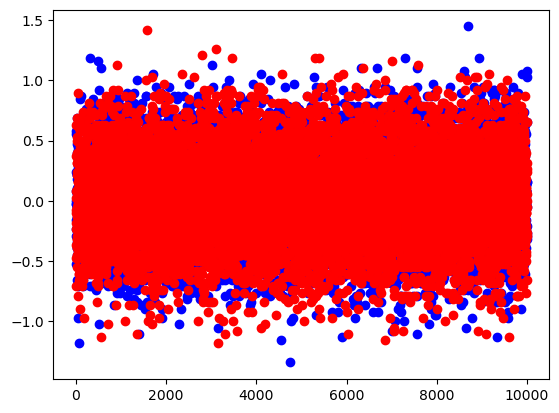

In [9]:
'''
Feedback
'''

soc.tproc.set_lfsr_cfg(2) # set the LFSR to update on a read, more can be found here: https://docs.qick.dev/latest/_autosummary/qick.drivers.tproc.html#qick.drivers.tproc.Axis_QICK_Proc.set_lfsr_cfg

class feedback_test(asm_v2.AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        shots = cfg['shots']
        gain = cfg['gain']
        feed_ch = cfg['feed_ch']

        self.declare_gen(ch=gen_ch)
        self.declare_gen(ch=feed_ch)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch,
                    name="mypulse",
                    freq=cfg['freq'],
                    phase=0,
                    length=cfg['pulse_len'],
                    style="const",
                    mode="oneshot",
                    stdysel="zero",
                    gain=gain,)
        
        self.add_pulse(ch=feed_ch,
                    name="feedpulse",
                    freq=1000,
                    phase=0,
                    length=0.5,
                    style="const",
                    mode="oneshot",
                    stdysel="zero",
                    gain=gain,)
        


        cfg['gain'] = 32766
        
        # Load all of the subroutines. These routines take config settings so load them first
        SETUP_PULSE(self, cfg)

        JUMP(self, "NOP")
        
        playPULSE1(self, gen_ch)
        playPULSE2(self, feed_ch)

        #these routines just need to be initialized, so set them second. Note that they are
        #loaded in order to ensure that inheritance is correct (i.e. later routines call earlier ones)

        fb_labels = [LFSR_sub, set_wport_on, set_wport_off, cond_out, read_and_jump, rand_amp]
        for label in fb_labels:
            label(self)
        
        #add a NOP at end of setup
        NOP(self)

        # Add a loop to repeat the above experiment n-times
        self.add_loop("ShotLoop", shots)
        # self.delay_auto(t=cfg['meas_delay'] + cfg['pulse_len'])



    def _body(self, cfg):

        # Use the call command and labels used in routines to call functions. First setup random amplitude or 
        # conditional out experiment
        
        #CALL(self, 'CONDOUT') # uncomment for conditional out experiment
        
        
        CALL(self, 'RANDAMP') # uncomment for random amplitude experiment
        
        CALL(self, 'playPULSE1')
        
        #call readout
        self.trigger(ros=[cfg['ro_ch']], t=cfg['trig_time'],  ddr4=True)

        # wait, then delay a bit extra
        self.wait_auto(cfg['feed_delay'])
        self.delay_auto(cfg['feed_delay'] + cfg['extra_delay'])

        # a second trigger ensures that the readout is fully filled
        self.trigger(ros=[cfg['ro_ch']], t=cfg['trig_time'],  ddr4=True)
        
        # add a conditional statement thresholded on the Q quadrature of the non-decimated readout buffer
        self.read_and_jump(cfg['ro_ch'], component = 'Q', threshold = 500, test = "<", label = 'NOPULSE')

        # if it is less than threshold, play this pulse
        self.pulse(ch=cfg['feed_ch'], name="feedpulse", t=0)
        
        # if not, it will jump to this label, skipping the second pulse
        self.label("NOPULSE")

        # add a small delay at end of experiment 
        self.delay_auto(t=cfg['meas_delay'] + cfg['pulse_len'])


config = {'gen_ch': 0,
          'feed_ch':2,
          'ro_ch': 4,
          'freq': 100,
          'phase':0,
          'trig_time': 0.01,
          'ro_len': 1,
          'shots': 10000,
          'meas_delay': 10,
          'pulse_len':1,
          'gain':1,
          "feed_delay": 0.2,
          'extra_delay': 0.0,
          }


prog = feedback_test(soccfg, reps=1, final_delay=.5, cfg=config)
d = prog.acquire(soc=soc, rounds=1)

i_data = d[0][0].T[0]
q_data = d[0][0].T[1]
mag = np.sqrt(i_data**2+q_data**2)

plt.plot(q_data, 'ob')
plt.plot(i_data, 'or')

In [10]:
'''
Print program out to show what is going on
'''
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	AsmInst(inst={'P_ADDR': 0, 'CMD': 'NOP'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 1, 'LINE': 1, 'LIT': '#32766', 'CMD': 'REG_WR', 'DST': 'w3', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 2, 'LINE': 2, 'LIT': '#0', 'CMD': 'REG_WR', 'DST': 'w1', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 3, 'LINE': 3, 'LIT': '#0', 'CMD': 'REG_WR', 'DST': 'w2', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 4, 'LINE': 4, 'LIT': '#430', 'CMD': 'REG_WR', 'DST': 'w4', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 5, 'LINE': 5, 'LIT': '#9', 'CMD': 'REG_WR', 'DST': 'w5', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 6, 'LINE': 6, 'LIT': '#44810940', 'CMD': 'REG_WR', 'DST': 'w0', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 7, 'LINE': 7, 'CMD': 'WMEM_WR', 'DST': '[&0]'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 0, 'CMD': 'NOP'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 1, 'LINE': 1, 'CMD': 'JUMP', 'LABEL': 'NOP'}, addr_inc=1)
	Label(label=